Any NaN in X: False
Any NaN in y: False


C:\Users\adity\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 19s 19ms/step - accuracy: 0.8217 - loss: 0.4957 - val_accuracy: 0.8643 - val_loss: 0.3565
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 17s 20ms/step - accuracy: 0.8827 - loss: 0.3254 - val_accuracy: 0.8937 - val_loss: 0.2908
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - accuracy: 0.8986 - loss: 0.2777 - val_accuracy: 0.8900 - val_loss: 0.2926
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 15s 17ms/step - accuracy: 0.9095 - loss: 0.2467 - val_accuracy: 0.8968 - val_loss: 0.2770
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 21s 25ms/step - accuracy: 0.9184 - loss: 0.2220 - val_accuracy: 0.9077 - val_loss: 0.2533
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 18s 21ms/step - accuracy: 0.9267 - loss: 0.1991 - val_accuracy: 0.9150 - val_loss: 0.2404
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 17s 20ms/step - accuracy: 0.9334 - loss: 0.1794 - val_accuracy: 0.9153 - val_loss: 0.2350
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 17s 20ms/step - accuracy: 0.9405 - loss: 0.1620 - 

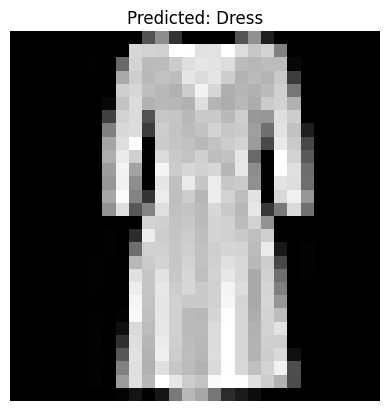

In [1]:
# =========================================
# 1. Import Libraries
# =========================================
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# =========================================
# 2. Load CSV Dataset
# =========================================
train_df = pd.read_csv("fashion-mnist_train.csv")
test_df = pd.read_csv("fashion-mnist_test.csv")

# =========================================
# 3. CLEAN DATA (VERY IMPORTANT)
# =========================================

# Convert everything to numeric (handles errors)
train_df = train_df.apply(pd.to_numeric, errors='coerce')
test_df = test_df.apply(pd.to_numeric, errors='coerce')

# Replace NaN values with 0
train_df = train_df.fillna(0)
test_df = test_df.fillna(0)

# =========================================
# 4. Separate Features and Labels
# =========================================
X = train_df.drop("label", axis=1).values.astype("float32")
y = train_df["label"].values.astype("int32")

X_test = test_df.drop("label", axis=1).values.astype("float32")
y_test = test_df["label"].values.astype("int32")

# =========================================
# 5. Normalize (0–255 → 0–1)
# =========================================
X = X / 255.0
X_test = X_test / 255.0

# =========================================
# 6. Reshape for CNN
# =========================================
X = X.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# =========================================
# 7. DEBUG CHECK (IMPORTANT)
# =========================================
print("Any NaN in X:", np.isnan(X).any())
print("Any NaN in y:", np.isnan(y).any())

# =========================================
# 8. Train / Validation Split
# =========================================
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.1, random_state=42
)

# =========================================
# 9. Build CNN Model
# =========================================
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# =========================================
# 10. Compile Model
# =========================================
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# =========================================
# 11. Train Model
# =========================================
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_val, y_val)
)

# =========================================
# 12. Evaluate Model
# =========================================
test_loss, test_acc = model.evaluate(X_test, y_test)
print("\n✅ Test Accuracy:", test_acc)

# =========================================
# 13. Predictions
# =========================================
predictions = model.predict(X_test)

# =========================================
# 14. Class Labels
# =========================================
class_names = [
    "T-shirt", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

# =========================================
# 15. Show Prediction Example
# =========================================
index = 10  # change this to see different samples

plt.imshow(X_test[index].reshape(28,28), cmap='gray')
# plt.title(f"Predicted: {class_names[np.argmax(predictions[index])]}")
plt.title(f"Predicted: {class_names[np.argmax(predictions[index])]} ({np.max(predictions[index]) * 100:.2f}%)")
plt.axis('off')
plt.show()

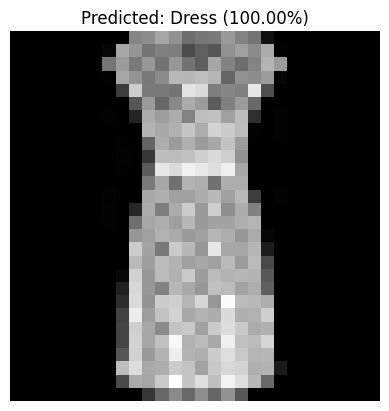

In [13]:
index = 70  # change this to see different samples

plt.imshow(X_test[index].reshape(28,28), cmap='gray')
# plt.title(f"Predicted: {class_names[np.argmax(predictions[index])]}")
plt.title(f"Predicted: {class_names[np.argmax(predictions[index])]} ({np.max(predictions[index]) * 100:.2f}%)")
plt.axis('off')
plt.show()